In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [77]:
# cykl 2017-2018
demo = pd.read_sas(r"DEMO_J.xpt", format="xport") #dane demograficzne
bmx = pd.read_sas(r"BMX_J.xpt", format="xport") #BMI
bpx = pd.read_sas(r"BPQ_J.xpt", format="xport") #cisnienie
alc = pd.read_sas(r"ALQ_J.xpt", format="xport")  # alkohol
diq = pd.read_sas(r"DIQ_J.xpt", format="xport") #czy zdiagnozowany na cukrzyce 
dpq = pd.read_sas(r"DPQ_J.xpt", format="xport") #DEPRESJA
fsq = pd.read_sas(r"FSQ_J.xpt", format="xport") #bezpieczeństwo żywnościowe
mcq = pd.read_sas(r"MCQ_J.xpt", format="xport") #stany chorobowe
paq = pd.read_sas(r"PAQ_J.xpt", format="xport") #aktywność fizyczna
slq = pd.read_sas(r"SLQ_J.xpt", format="xport") #zaburzenia snu
smq = pd.read_sas(r"SMQ_J.xpt", format="xport") # papierosy

#połączenie – rozszerzony zbiór cech 
df = demo.merge(bmx, on="SEQN")
df = df.merge(bpx, on="SEQN")
df = df.merge(alc, on="SEQN")
df = df.merge(diq, on="SEQN")
df = df.merge(dpq, on="SEQN")
df = df.merge(fsq, on="SEQN")
df = df.merge(mcq, on="SEQN")
df = df.merge(paq, on="SEQN")
df = df.merge(slq, on="SEQN")
df = df.merge(smq, on="SEQN")

print(f"Rekordów df1: {len(df)}")

Rekordów df1: 5533


In [78]:
def prepare_classification_dataset(df):
    data = df.copy()

    dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
    for col in dpq_cols:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan)
            
    data = data.dropna(subset=dpq_cols)
    data['PHQ9_score'] = data[dpq_cols].sum(axis=1)
    
    data['depression'] = (data['PHQ9_score'] >= 10).astype(int)
    
    features_demo = ['RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR']
    features_lifestyle = ['BMXBMI', 'SLD010H', 'ALQ130', 'SMQ020', 'PAQ605', 'PAQ650', 'FSD032A', 'FSD032B']
    features_diseases = ['DIQ010', 'BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L']
    
    all_features = features_demo + features_lifestyle + features_diseases
    available_cols = [col for col in all_features if col in data.columns]

    data = data[available_cols + ['depression']].copy()
    #czyszczenie braków (błędnych odpowiedzi)
    binary_cols = ['BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L', 'PAQ605', 'PAQ650', 'SMQ020']
    for col in binary_cols:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan).replace(2, 0)
            
    if 'DIQ010' in data.columns:
        data['DIQ010'] = data['DIQ010'].replace([7, 9], np.nan).replace([2, 3], 0)

    for col in ['FSD032A', 'FSD032B', 'DMDEDUC2']:
        if col in data.columns:
            data[col] = data[col].replace([7, 9], np.nan)
            
    if 'DMDMARTL' in data.columns: 
        data['DMDMARTL'] = data['DMDMARTL'].replace([77, 99], np.nan)
        
    if 'SLD010H' in data.columns: 
        data['SLD010H'] = data['SLD010H'].replace([77, 99], np.nan)
        
    if 'ALQ130' in data.columns: 
        data['ALQ130'] = data['ALQ130'].replace([777, 999], np.nan)
        
    return data

data_class = prepare_classification_dataset(df)

print(f"Ilość pacjentów: {data_class.shape[0]}")
print(f"Przypadki depresji: {data_class['depression'].sum()} ({data_class['depression'].mean()*100:.1f}%)")

Ilość pacjentów: 5068
Przypadki depresji: 459 (9.1%)


In [79]:
data_class.columns

Index(['RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR', 'BMXBMI',
       'ALQ130', 'SMQ020', 'PAQ605', 'PAQ650', 'FSD032A', 'FSD032B', 'DIQ010',
       'BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L', 'depression'],
      dtype='object')

# Trenowanie modeli

In [80]:
from sklearn.impute import KNNImputer
X1 = data_class.drop(columns=["depression"])
y1 = data_class["depression"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1)

imputer = KNNImputer(n_neighbors=5) 
X_train_imp = pd.DataFrame(imputer.fit_transform(X1_train), columns=X1_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X1_test), columns=X1_test.columns)

scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X_train_imp)
X1_test_sc  = scaler1.transform(X_test_imp)

lr1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr1.fit(X1_train_sc, y1_train)

y1_pred = lr1.predict(X1_test_sc)
y1_prob = lr1.predict_proba(X1_test_sc)[:, 1]

In [81]:
smote = SMOTE(random_state=RANDOM_STATE)
X1_train_sm, y1_train_sm = smote.fit_resample(X_train_imp, y1_train)

lgbm = lgb.LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    num_leaves=31, 
    max_depth=-1, 
    random_state=RANDOM_STATE, 
    verbosity=-1)
lgbm.fit(X1_train_sm, y1_train_sm)

y_lgbm_pred = lgbm.predict(X1_test)
y_lgbm_prob = lgbm.predict_proba(X1_test)[:, 1]


In [82]:
xgboost = xgb.XGBClassifier(
    objective='binary:logistic', 
    n_estimators=100,learning_rate=0.1, 
    max_depth=4, 
    eval_metric='logloss', 
    random_state=RANDOM_STATE)
xgboost.fit(X1_train_sm, y1_train_sm)

y_xgb_pred = xgboost.predict(X1_test)
y_xgb_prob = xgboost.predict_proba(X1_test)[:, 1]

In [83]:
cat_features = [
    'RIAGENDR', 'DMDEDUC2', 'DMDMARTL',
    'FSD032A', 'FSD032B', 'SMQ020', 
    'PAQ605', 'PAQ650',
    'DIQ010', 'BPQ020', 'SLQ050', 'MCQ160B', 'MCQ010', 'MCQ160L'
]

for col in cat_features:
    data_class[col] = data_class[col].astype(str)

X = data_class.drop(columns=['depression'])
y = data_class['depression']
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [86]:
catboost = CatBoostClassifier(
    iterations=500,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=False
)
catboost.fit(X_train_cb, y_train_cb)

y_cb_pred = catboost.predict(X_test_cb)
y_cb_prob = catboost.predict_proba(X_test_cb)[:, 1]

In [87]:
#bez usuwania Nan - imputer
models = [
    ("LR (podstawowe)",  y1_test, y1_pred, y1_prob),
    ("LightGBM",         y1_test, y_lgbm_pred, y_lgbm_prob),
    ("XGBoost",          y1_test, y_xgb_pred, y_xgb_prob),
    ("Catboost",         y_test_cb, y_cb_pred, y_cb_prob),
]

rows = []
for name, yt, yp, ypr in models:
    rep = classification_report(yt, yp, output_dict=True)
    rows.append({
        "Model"        : name,
        "Accuracy"     : round(accuracy_score(yt, yp), 4),
        "ROC AUC"      : round(roc_auc_score(yt, ypr), 4),
        "Avg Precision": round(average_precision_score(yt, ypr), 4),
        "F1 (macro)"   : round(f1_score(yt, yp, average='macro'), 4),
        "Precision (1)": round(rep['1']['precision'], 4),
        "Recall (1)"   : round(rep['1']['recall'], 4),
        "F1 (1)"       : round(rep['1']['f1-score'], 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

                 Accuracy  ROC AUC  Avg Precision  F1 (macro)  Precision (1)  Recall (1)  F1 (1)
Model                                                                                           
LR (podstawowe)    0.7278   0.7677         0.2715      0.5686         0.1993      0.6630  0.3065
LightGBM           0.9053   0.7510         0.2351      0.5306         0.3750      0.0652  0.1111
XGBoost            0.9083   0.7355         0.2411      0.5155         0.4444      0.0435  0.0792
Catboost           0.8304   0.7272         0.2570      0.5993         0.2368      0.3913  0.2951


In [88]:
print(f"Wyniki klasyfikacji dla CatBoost:")
print(classification_report(y_test_cb, y_cb_pred))

Wyniki klasyfikacji dla CatBoost:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       922
           1       0.24      0.39      0.30        92

    accuracy                           0.83      1014
   macro avg       0.59      0.63      0.60      1014
weighted avg       0.87      0.83      0.85      1014



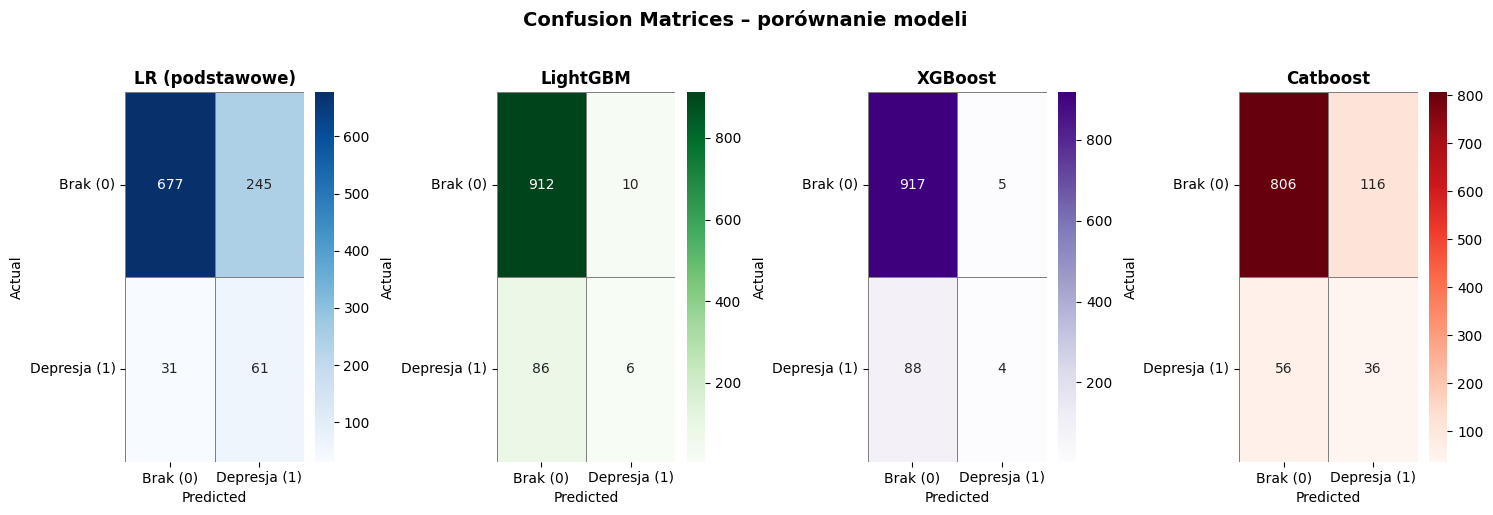

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
cmaps = ['Blues', 'Greens', 'Purples', 'Reds']

for ax, (name, yt, yp, _), cmap in zip(axes, models, cmaps):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, linewidths=0.5, linecolor='grey')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Brak (0)', 'Depresja (1)'])
    ax.set_yticklabels(['Brak (0)', 'Depresja (1)'], rotation=0)

fig.suptitle('Confusion Matrices – porównanie modeli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## WIelochorobowość

In [40]:
from functools import reduce

demo = pd.read_sas("DEMO_J.xpt")[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR']]
fsq = pd.read_sas("FSQ_J.xpt")[['SEQN', 'FSD032A', 'FSD032B']] #żywienie
hoq = pd.read_sas("HOQ_J.xpt")[['SEQN', 'HOQ065']] #stan mieszkaniowy
hiq = pd.read_sas("HIQ_J.xpt")[['SEQN', 'HIQ011']]  #ubezpieczenie zdrowotne
smq = pd.read_sas("SMQ_J.xpt")[['SEQN', 'SMQ020']] #papierosy
smq_fam = pd.read_sas("SMQFAM_J.xpt")[['SEQN', 'SMD460']] #palenie w rodzinie
alq = pd.read_sas("ALQ_J.xpt")[['SEQN', 'ALQ130']] #alkohol
duq = pd.read_sas("DUQ_J.xpt")[['SEQN', 'DUQ240']] #narkotyki
bmx = pd.read_sas("BMX_J.xpt")[['SEQN', 'BMXBMI']] #BMI
cbc = pd.read_sas("CBC_J.xpt")[['SEQN', 'LBXHGB']] #hemoglobina
bpx_exam = pd.read_sas("BPX_J.xpt")[['SEQN', 'BPXSY1', 'BPXDI1']] #ciśnienie
glu = pd.read_sas("GLU_J.xpt")[['SEQN', 'LBXGLU']] #glukoza na czczo

dr1 = pd.read_sas("DR1TOT_J.xpt")[['SEQN', 'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12']]

#depresja
dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
dpq = pd.read_sas("DPQ_J.xpt")[['SEQN'] + dpq_cols]

diq = pd.read_sas("DIQ_J.xpt")[['SEQN', 'DIQ010']] #cukrzyca
bpq = pd.read_sas("BPQ_J.xpt")[['SEQN', 'BPQ020']] #nadciśnienie 
mcq = pd.read_sas("MCQ_J.xpt")[['SEQN', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']]

#łączenie
dfs = [demo, fsq, hoq, hiq, smq, smq_fam, alq, duq, bmx, cbc, bpx_exam, glu, dr1, dpq, diq, bpq, mcq]
df = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dfs)

#wybranie osób z wielochorobowością - minimum 2 choroby
disease_cols = ['DIQ010', 'BPQ020', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']

for col in disease_cols:
    df[col] = df[col].replace([7, 9], 0) 
    df[col] = df[col].apply(lambda x: 1 if x == 1 else 0)

df['disease_count'] = df[disease_cols].sum(axis=1)
df = df[df['disease_count'] >= 2].copy()

#wyliczenie depresji 
for col in dpq_cols:
    df[col] = df[col].replace([7, 9], np.nan)
df = df.dropna(subset=dpq_cols) 
df['depression'] = (df[dpq_cols].sum(axis=1) >= 10).astype(int)

#czyszczenie braków
for col in ['HOQ065', 'HIQ011']:
    df[col] = df[col].replace([7, 9], np.nan)

#0 - nieubezpieczony zamiast 2
df['HIQ011'] = df['HIQ011'].replace(2, 0)

binary_features = ['SMQ020', 'SMD460', 'DUQ240']
for col in binary_features:
    df[col] = df[col].replace([7, 9], np.nan).replace(2, 0) 

df['FSD032A'] = df['FSD032A'].replace([7, 9], np.nan)
df['FSD032B'] = df['FSD032B'].replace([7, 9], np.nan)
df['DMDEDUC2'] = df['DMDEDUC2'].replace([7, 9], np.nan)
df['DMDMARTL'] = df['DMDMARTL'].replace([77, 99], np.nan)
df['ALQ130'] = df['ALQ130'].replace([777, 999], np.nan)

final_features = [
    'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR', #demografia
    'HOQ065', 'HIQ011', #mieszkanie i ubezpieczenie
    'FSD032A', 'FSD032B', #żywność
    'SMQ020', 'ALQ130', 'DUQ240', 'SMD460', #używki
    'BMXBMI', 'LBXHGB', #krew
    'BPXSY1', 'BPXDI1', 'LBXGLU', #ciśnienie skurczowe, rozkurczowe i glukoza
    'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12' #dieta
]

data_model = df[final_features + ['depression']].copy()

data_model.shape

(389, 23)

In [41]:
data_model.isna().sum()

RIDAGEYR        0
RIAGENDR        0
DMDEDUC2        3
DMDMARTL        3
RIDRETH3        0
INDFMPIR       48
HOQ065         12
HIQ011          2
FSD032A        12
FSD032B        12
SMQ020          0
ALQ130        149
DUQ240          9
SMD460         12
BMXBMI          4
LBXHGB          7
BPXSY1         43
BPXDI1         43
LBXGLU          8
DR1TCAFF       12
DR1TTHEO       12
DR1TVB12       12
depression      0
dtype: int64

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from catboost import CatBoostClassifier
import optuna

#podział na cechy kategoryczne i liczbowe
cat_features = ['RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'HOQ065', 
                'HIQ011', 'FSD032A', 'FSD032B', 'SMQ020', 'SMD460', 'DUQ240']

for col in cat_features:
    data_model[col] = data_model[col].astype(str)

X = data_model.drop(columns=['depression'])
y = data_model['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
def objective_balanced(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',            
        'cat_features': cat_features,
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    return auc

study_balanced = optuna.create_study(direction='maximize') 
study_balanced.optimize(objective_balanced, n_trials=40)  

print(f"Najlepsze parametry: {study_balanced.best_params}")
print(f"Najlepsze AUC: {study_balanced.best_value}")

best_model_balanced = CatBoostClassifier(**study_balanced.best_params, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)
best_model_balanced.fit(X_train, y_train)

print(classification_report(y_test, best_model_balanced.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_balanced.predict_proba(X_test)[:, 1]):.4f}")

[I 2026-05-09 12:39:40,086] A new study created in memory with name: no-name-441ccc85-f676-4ecb-b2f7-693b3ee68af1
[I 2026-05-09 12:39:43,210] Trial 0 finished with value: 0.6272321428571428 and parameters: {'iterations': 316, 'learning_rate': 0.01504548344866413, 'depth': 8, 'l2_leaf_reg': 7.207376003820658}. Best is trial 0 with value: 0.6272321428571428.
[I 2026-05-09 12:39:45,567] Trial 1 finished with value: 0.6595982142857143 and parameters: {'iterations': 208, 'learning_rate': 0.04906394639240648, 'depth': 6, 'l2_leaf_reg': 5.064982946635423}. Best is trial 1 with value: 0.6595982142857143.
[I 2026-05-09 12:39:48,103] Trial 2 finished with value: 0.6529017857142858 and parameters: {'iterations': 377, 'learning_rate': 0.08634994136090376, 'depth': 6, 'l2_leaf_reg': 4.168104245696437}. Best is trial 1 with value: 0.6595982142857143.
[I 2026-05-09 12:39:50,618] Trial 3 finished with value: 0.6651785714285714 and parameters: {'iterations': 137, 'learning_rate': 0.05195261426852932, '

Najlepsze parametry: {'iterations': 150, 'learning_rate': 0.025056497338739107, 'depth': 6, 'l2_leaf_reg': 2.2867604965114174}
Najlepsze AUC: 0.7310267857142857
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        64
           1       0.21      0.29      0.24        14

    accuracy                           0.68        78
   macro avg       0.52      0.53      0.52        78
weighted avg       0.72      0.68      0.70        78

ROC-AUC: 0.6217


<Axes: >

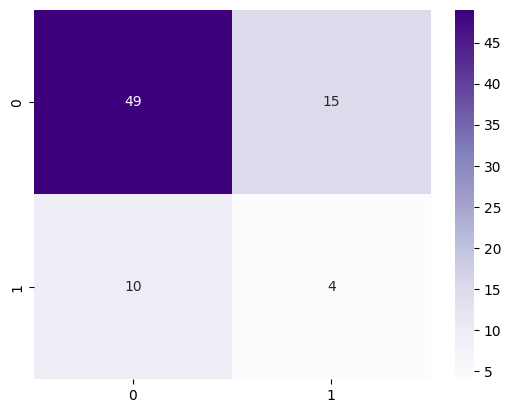

In [56]:
cm = confusion_matrix(y_test, best_model_balanced.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")


### Ze SMOTE 

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

X = data_model.drop(columns=['depression']).astype(float)
y = data_model['depression'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='most_frequent') 
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print(f"NaN przed SMOTE: {X_train_imp.isna().sum().sum()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

print(f"Liczność klas po SMOTE:\n{y_train_smote.value_counts()}")

NaN przed SMOTE: 0
Liczność klas po SMOTE:
depression
0    253
1    253
Name: count, dtype: int64


In [44]:
def objective_smote(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train_smote, y_train_smote, eval_set=[(X_test_imp, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test_imp)[:, 1]
    return roc_auc_score(y_test, preds_proba)

study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=40)

print(f"Najlepsze parametry: {study_smote.best_params}")
print(f"Najlepsze AUC: {study_smote.best_value}")

best_model_smote = CatBoostClassifier(**study_smote.best_params, verbose=False)
best_model_smote.fit(X_train_smote, y_train_smote)

print(classification_report(y_test, best_model_smote.predict(X_test_imp)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_smote.predict_proba(X_test_imp)[:, 1]):.4f}")

[I 2026-05-09 12:46:23,650] A new study created in memory with name: no-name-28164d45-1341-4024-848f-9c029c1962ec
[I 2026-05-09 12:46:23,837] Trial 0 finished with value: 0.6110491071428572 and parameters: {'iterations': 361, 'learning_rate': 0.01892424527259533, 'depth': 6, 'l2_leaf_reg': 7.558394402203422}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:23,962] Trial 1 finished with value: 0.5457589285714286 and parameters: {'iterations': 104, 'learning_rate': 0.12637138588106003, 'depth': 4, 'l2_leaf_reg': 4.150616266218643}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:24,153] Trial 2 finished with value: 0.5457589285714286 and parameters: {'iterations': 389, 'learning_rate': 0.16920015537825345, 'depth': 4, 'l2_leaf_reg': 9.550407074782111}. Best is trial 0 with value: 0.6110491071428572.
[I 2026-05-09 12:46:24,342] Trial 3 finished with value: 0.62109375 and parameters: {'iterations': 478, 'learning_rate': 0.02405183043198923, 'depth': 

Najlepsze parametry: {'iterations': 324, 'learning_rate': 0.02146667435548067, 'depth': 8, 'l2_leaf_reg': 8.439491603030902}
Najlepsze AUC: 0.6908482142857143
              precision    recall  f1-score   support

           0       0.80      0.81      0.81        64
           1       0.08      0.07      0.07        14

    accuracy                           0.68        78
   macro avg       0.44      0.44      0.44        78
weighted avg       0.67      0.68      0.67        78

ROC-AUC: 0.5647


<Axes: >

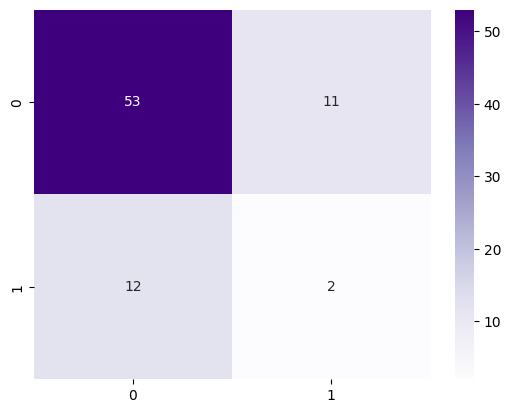

In [54]:
cm = confusion_matrix(y_test, best_model_smote.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")

## Bez multichorobowości

In [43]:
from functools import reduce

demo = pd.read_sas("DEMO_J.xpt")[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR']]
fsq = pd.read_sas("FSQ_J.xpt")[['SEQN', 'FSD032A', 'FSD032B']] #żywienie
hoq = pd.read_sas("HOQ_J.xpt")[['SEQN', 'HOQ065']] #stan mieszkaniowy
hiq = pd.read_sas("HIQ_J.xpt")[['SEQN', 'HIQ011']] #ubezpieczenie zdrowotne
smq = pd.read_sas("SMQ_J.xpt")[['SEQN', 'SMQ020']] #papierosy
smq_fam = pd.read_sas("SMQFAM_J.xpt")[['SEQN', 'SMD460']] #palenie w rodzinie
alq = pd.read_sas("ALQ_J.xpt")[['SEQN', 'ALQ130']] #alkohol
duq = pd.read_sas("DUQ_J.xpt")[['SEQN', 'DUQ240']] #narkotyki
bmx = pd.read_sas("BMX_J.xpt")[['SEQN', 'BMXBMI']] #BMI
cbc = pd.read_sas("CBC_J.xpt")[['SEQN', 'LBXHGB']] #hemoglobina
bpx_exam = pd.read_sas("BPX_J.xpt")[['SEQN', 'BPXSY1', 'BPXDI1']] #ciśnienie
glu = pd.read_sas("GLU_J.xpt")[['SEQN', 'LBXGLU']] #glukoza na czczo

dr1 = pd.read_sas("DR1TOT_J.xpt")[['SEQN', 'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12']]

#depresja
dpq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
dpq = pd.read_sas("DPQ_J.xpt")[['SEQN'] + dpq_cols]

diq = pd.read_sas("DIQ_J.xpt")[['SEQN', 'DIQ010']] #cukrzyca
bpq = pd.read_sas("BPQ_J.xpt")[['SEQN', 'BPQ020']] #nadciśnienie 
mcq = pd.read_sas("MCQ_J.xpt")[['SEQN', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']]

#łączenie danych
dfs = [demo, fsq, hoq, hiq, smq, smq_fam, alq, duq, bmx, cbc, bpx_exam, glu, dr1, dpq, diq, bpq, mcq]
df = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dfs)

disease_cols = ['DIQ010', 'BPQ020', 'MCQ160B', 'MCQ160C', 'MCQ160F', 'MCQ010', 'MCQ160L', 'MCQ220']

#wyliczenie depresji 
for col in dpq_cols:
    df[col] = df[col].replace([7, 9], np.nan)
df = df.dropna(subset=dpq_cols) 
df['depression'] = (df[dpq_cols].sum(axis=1) >= 10).astype(int)

#czyszczenie braków
for col in ['HOQ065', 'HIQ011']:
    df[col] = df[col].replace([7, 9], np.nan)

#0 - nieubezpieczony zamiast 2
df['HIQ011'] = df['HIQ011'].replace(2, 0)

binary_features = ['SMQ020', 'SMD460', 'DUQ240']
for col in binary_features:
    df[col] = df[col].replace([7, 9], np.nan).replace(2, 0) 

df['FSD032A'] = df['FSD032A'].replace([7, 9], np.nan)
df['FSD032B'] = df['FSD032B'].replace([7, 9], np.nan)
df['DMDEDUC2'] = df['DMDEDUC2'].replace([7, 9], np.nan)
df['DMDMARTL'] = df['DMDMARTL'].replace([77, 99], np.nan)
df['ALQ130'] = df['ALQ130'].replace([777, 999], np.nan)

final_features = [
    'RIDAGEYR', 'RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'INDFMPIR', #demografia
    'HOQ065', 'HIQ011', #mieszkanie i ubezpieczenie
    'FSD032A', 'FSD032B', #żywność
    'SMQ020', 'ALQ130', 'DUQ240', 'SMD460', #używki
    'BMXBMI', 'LBXHGB', #krew
    'BPXSY1', 'BPXDI1', 'LBXGLU', #ciśnienie skurczowe, rozkurczowe i glukoza
    'DR1TCAFF', 'DR1TTHEO', 'DR1TVB12' #dieta
]

data_model2 = df[final_features + ['depression']].copy()

data_model2.shape

(2037, 23)

In [44]:
cat_features = ['RIAGENDR', 'DMDEDUC2', 'DMDMARTL', 'RIDRETH3', 'HOQ065', 
                'HIQ011', 'FSD032A', 'FSD032B', 'SMQ020', 'SMD460', 'DUQ240']

for col in cat_features:
    data_model2[col] = data_model2[col].astype(str)

X = data_model2.drop(columns=['depression'])
y = data_model2['depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

[I 2026-05-09 17:52:19,708] A new study created in memory with name: no-name-d254dcbd-98d2-4fa0-b7ef-0d8d35199bd7
[I 2026-05-09 17:52:21,228] Trial 0 finished with value: 0.7121812243763462 and parameters: {'iterations': 345, 'learning_rate': 0.17951297965355592, 'depth': 6, 'l2_leaf_reg': 8.256934586089297}. Best is trial 0 with value: 0.7121812243763462.
[I 2026-05-09 17:52:22,940] Trial 1 finished with value: 0.7538392050587173 and parameters: {'iterations': 407, 'learning_rate': 0.09655725296995596, 'depth': 6, 'l2_leaf_reg': 8.641321028149285}. Best is trial 1 with value: 0.7538392050587173.
[I 2026-05-09 17:52:25,660] Trial 2 finished with value: 0.7094017094017094 and parameters: {'iterations': 408, 'learning_rate': 0.11550062762953806, 'depth': 8, 'l2_leaf_reg': 2.88558081920592}. Best is trial 1 with value: 0.7538392050587173.
[I 2026-05-09 17:52:28,547] Trial 3 finished with value: 0.7205197693002571 and parameters: {'iterations': 315, 'learning_rate': 0.10316805455547169, 'd

Najlepsze parametry: {'iterations': 492, 'learning_rate': 0.010267777600991264, 'depth': 7, 'l2_leaf_reg': 7.011783389552878}
Najlepsze AUC: 0.7745118476825794
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       369
           1       0.24      0.51      0.33        39

    accuracy                           0.80       408
   macro avg       0.59      0.67      0.60       408
weighted avg       0.87      0.80      0.83       408

ROC-AUC: 0.7213


<Axes: >

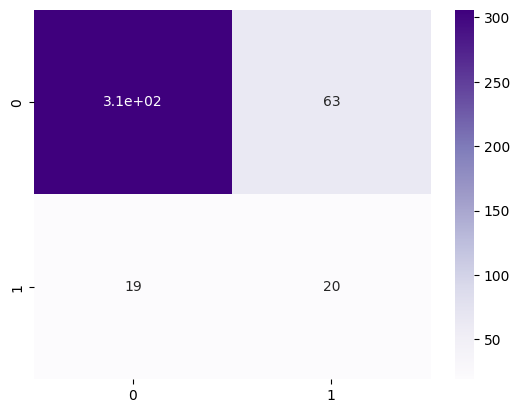

In [45]:
def objective_balanced(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',            
        'cat_features': cat_features,
        'random_seed': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=30)
    
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    return auc

study_cb = optuna.create_study(direction='maximize') 
study_cb.optimize(objective_balanced, n_trials=20)  

print(f"Najlepsze parametry: {study_cb.best_params}")
print(f"Najlepsze AUC: {study_cb.best_value}")

best_model_catb = CatBoostClassifier(**study_cb.best_params, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)
best_model_catb.fit(X_train, y_train)

print(classification_report(y_test, best_model_catb.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_model_catb.predict_proba(X_test)[:, 1]):.4f}")

cm = confusion_matrix(y_test, best_model_catb.predict(X_test))
sns.heatmap(cm, annot=True, cmap="Purples")

Accuracy (0.35): 0.5416666666666666

Classification Report (0.35):
              precision    recall  f1-score   support

           0       0.95      0.52      0.67       369
           1       0.14      0.74      0.24        39

    accuracy                           0.54       408
   macro avg       0.55      0.63      0.45       408
weighted avg       0.87      0.54      0.63       408



<Axes: >

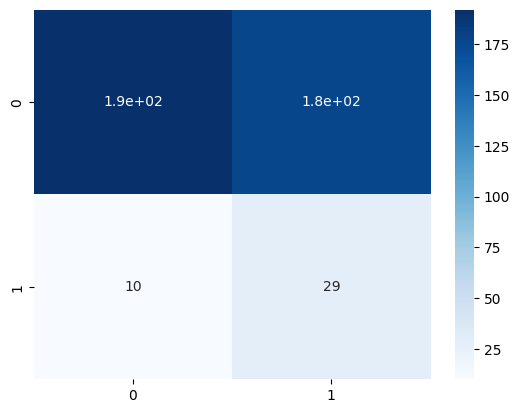

In [50]:
y_prob_035 = (best_model_catb.predict_proba(X_test)[:, 1]>0.35).astype(int)
cm_035 = confusion_matrix(y_test, y_prob_035)
print("Accuracy (0.35):", accuracy_score(y_test, y_prob_035))
print("\nClassification Report (0.35):")
print(classification_report(y_test, y_prob_035))
sns.heatmap(cm_035, annot=True, cmap="Blues")

Accuracy (0.45): 0.7058823529411765

Classification Report (0.45):
              precision    recall  f1-score   support

           0       0.94      0.72      0.82       369
           1       0.17      0.54      0.26        39

    accuracy                           0.71       408
   macro avg       0.55      0.63      0.54       408
weighted avg       0.86      0.71      0.76       408



<Axes: >

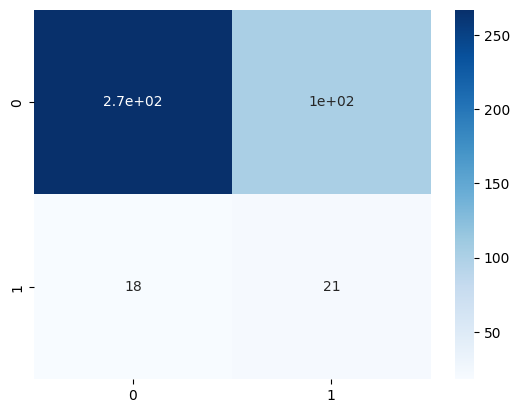

In [51]:
y_prob_045 = (best_model_catb.predict_proba(X_test)[:, 1]>0.45).astype(int)
cm_045 = confusion_matrix(y_test, y_prob_045)
print("Accuracy (0.45):", accuracy_score(y_test, y_prob_045))
print("\nClassification Report (0.45):")
print(classification_report(y_test, y_prob_045))
sns.heatmap(cm_045, annot=True, cmap="Blues")